CNN Foundations

Goal:
- understand image tensors
- understand convolution
- understand pooling
- build a small CNN
- learn to track shapes correctly

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


Images as tensors

In PyTorch, image tensors usually have shape:

(batch_size, channels, height, width)

This is often written as:

(N, C, H, W)


In [3]:
image = torch.randn(1,3,32,32)

print("shape:", image.shape)
print("batch size:", image.shape[0])
print("channels:", image.shape[1])
print("height:", image.shape[2])
print("width:", image.shape[3])



shape: torch.Size([1, 3, 32, 32])
batch size: 1
channels: 3
height: 32
width: 32


Grayscale vs RGB

Grayscale image:
channels = 1

RGB image:
channels = 3

In [4]:
gray_image = torch.randn(1, 1, 28, 28)
rgb_image = torch.randn(1, 3, 28, 28)

print("gray shape:", gray_image.shape)
print("rgb shape:", rgb_image.shape)

gray shape: torch.Size([1, 1, 28, 28])
rgb shape: torch.Size([1, 3, 28, 28])


Batch of images

A model usually processes many images at once.


In [5]:
batch = torch.randn(8, 3, 64, 64)

print("batch shape:", batch.shape)
print("number of images:", batch.shape[0])

batch shape: torch.Size([8, 3, 64, 64])
number of images: 8


What is convolution?

A convolution layer uses learnable filters (kernels)
to scan across the image and produce feature maps.

In PyTorch:
nn.Conv2d(in_channels, out_channels, kernel_size)


In [6]:
conv = nn.Conv2d(in_channels=3, out_channels= 8, kernel_size=3)
print(conv)
print("weight shape:", conv.weight.shape)
print("bias shape:", conv.bias.shape)


Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
weight shape: torch.Size([8, 3, 3, 3])
bias shape: torch.Size([8])


Conv2d weight shape

For Conv2d, weight shape is:

(out_channels, in_channels, kernel_height, kernel_width)

In [7]:
# Pass an image through a convolution layer
x = torch.randn(1, 3, 32, 32)
y = conv(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([1, 3, 32, 32])
output shape: torch.Size([1, 8, 30, 30])


 Why did the height and width change?

With kernel_size = 3 and no padding,
the output becomes smaller.

Default stride = 1
Default padding = 0

Output size formula

For one spatial dimension:

output = floor((input + 2*padding - kernel_size) / stride) + 1


In [8]:
input_size = 32
kernel_size = 3
padding = 0
stride = 1

output_size = ((input_size + 2 * padding - kernel_size) // stride) + 1
print(output_size)


30


In [9]:
conv_no_padding = nn.Conv2d(3, 8, kernel_size=3, padding=0)
conv_with_padding = nn.Conv2d(3, 8, kernel_size=3, padding=1)

x = torch.randn(1, 3, 32, 32)

y1 = conv_no_padding(x)
y2 = conv_with_padding(x)

print("no padding output shape:", y1.shape)
print("with padding output shape:", y2.shape)

no padding output shape: torch.Size([1, 8, 30, 30])
with padding output shape: torch.Size([1, 8, 32, 32])


Stride changes how fast we move the filter
Larger stride usually makes output smaller.

In [10]:
conv_stride1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
conv_stride2 = nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1)

x = torch.randn(1, 3, 32, 32)

y1 = conv_stride1(x)
y2 = conv_stride2(x)

print("stride 1 output shape:", y1.shape)
print("stride 2 output shape:", y2.shape)

stride 1 output shape: torch.Size([1, 8, 32, 32])
stride 2 output shape: torch.Size([1, 8, 16, 16])


Feature maps

Each output channel is a feature map.

If out_channels = 8,
the convolution produces 8 feature maps.

In [13]:
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)
x = torch.randn(1, 3, 32, 32)
y = conv(x)

print("output shape:", y.shape)
print("number of feature maps:", y.shape[1])

output shape: torch.Size([1, 8, 32, 32])
number of feature maps: 8


Visualize one fake channel from one fake image
This is random data, so it will not look meaningful.
But it helps build intuition.


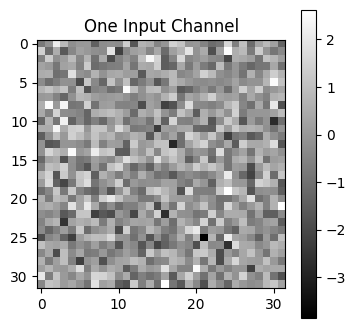

In [14]:
single_channel = x[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(single_channel.numpy(), cmap="gray")
plt.title("One Input Channel")
plt.colorbar()
plt.show()

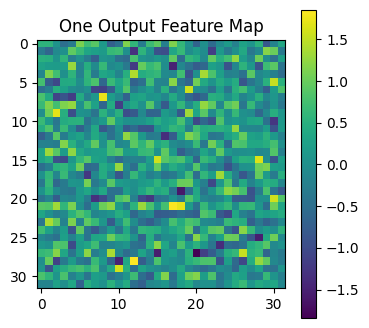

In [15]:
feature_map = y[0, 0].detach()

plt.figure(figsize=(4, 4))
plt.imshow(feature_map.numpy(), cmap="viridis")
plt.title("One Output Feature Map")
plt.colorbar()
plt.show()

Activation after convolution
A common pattern is:
Conv -> ReLU

In [16]:
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)

x = torch.randn(1, 3, 32, 32)
y = conv(x)
y_relu = torch.relu(y)

print("conv output shape:", y.shape)
print("relu output shape:", y_relu.shape)

conv output shape: torch.Size([1, 8, 32, 32])
relu output shape: torch.Size([1, 8, 32, 32])


Pooling

Pooling reduces spatial dimensions.

Common choice:
MaxPool2d

In [17]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

x = torch.randn(1, 8, 32, 32)
y = pool(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([1, 8, 32, 32])
output shape: torch.Size([1, 8, 16, 16])


Why pooling?

Pooling can:
- reduce computation
- reduce spatial size
- keep stronger responses
- add some translation robustness

In [18]:
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

x = torch.randn(1, 8, 32, 32)
y_avg = avg_pool(x)

print("avg pool output shape:", y_avg.shape)


avg pool output shape: torch.Size([1, 8, 16, 16])


A standard CNN block

Conv -> ReLU -> Pool

In [19]:
block = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2)
)
x = torch.randn(1, 3, 32, 32)
y = block(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([1, 3, 32, 32])
output shape: torch.Size([1, 8, 16, 16])


Stacking CNN blocks

In [20]:
cnn_features = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(8, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2)
)

x = torch.randn(1, 3, 32, 32)
y = cnn_features(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([1, 3, 32, 32])
output shape: torch.Size([1, 16, 8, 8])


Flattening

Fully connected layers expect shape:
(batch_size, features)

So after convolution blocks, we often flatten.

In [21]:
x = torch.randn(4, 16, 8, 8)

flat = x.view(x.shape[0], -1)

print("before flatten:", x.shape)
print("after flatten:", flat.shape)

before flatten: torch.Size([4, 16, 8, 8])
after flatten: torch.Size([4, 1024])


 Why flattening works here

If shape is:
(4, 16, 8, 8)

Then each example has:
16 * 8 * 8 = 1024 features

Build a full small CNN

In [22]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 8 * 8, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.shape[0], -1)
        x = self.classifier(x)
        return x


In [23]:
model = SmallCNN()
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)


Test the CNN on fake image batches


In [24]:
x = torch.randn(8, 3, 32, 32)
y = model(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([8, 3, 32, 32])
output shape: torch.Size([8, 10])


Interpret the output

Output shape:
(batch_size, num_classes)

If output is (8, 10),
that means:
- batch size = 8
- 10 class scores per image

In [25]:
print(y[0])
print("shape of one prediction:", y[0].shape)

tensor([ 0.3620,  0.0614,  0.0227, -0.1552,  0.1992, -0.2371,  0.1778,  0.2524,
        -0.1668,  0.0972], grad_fn=<SelectBackward0>)
shape of one prediction: torch.Size([10])


Predicted class with argmax

In [26]:
pred_classes = torch.argmax(y, dim=1)

print(pred_classes)
print(pred_classes.shape)

tensor([0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([8])


Create fake labels for a classification example



In [27]:
labels = torch.randint(0, 10, (8,))
print(labels)

tensor([9, 1, 4, 7, 9, 0, 4, 2])


Classification loss: CrossEntropyLoss

In [28]:
criterion = nn.CrossEntropyLoss()
loss = criterion(y, labels)

print("loss:", loss.item())

loss: 2.2350306510925293


One training step with fake data

In [29]:
model = SmallCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

x = torch.randn(8, 3, 32, 32)
labels = torch.randint(0, 10, (8,))

outputs = model(x)
loss = criterion(outputs, labels)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("training step complete")
print("loss:", loss.item())

training step complete
loss: 2.34428071975708


In [30]:
class DebugCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        print("input:", x.shape)

        x = self.conv1(x)
        print("after conv1:", x.shape)

        x = torch.relu(x)
        x = self.pool(x)
        print("after pool1:", x.shape)

        x = self.conv2(x)
        print("after conv2:", x.shape)

        x = torch.relu(x)
        x = self.pool(x)
        print("after pool2:", x.shape)

        x = x.view(x.shape[0], -1)
        print("after flatten:", x.shape)

        x = self.fc1(x)
        print("after fc1:", x.shape)

        x = torch.relu(x)
        x = self.fc2(x)
        print("after fc2:", x.shape)

        return x

In [31]:
debug_model = DebugCNN()
x = torch.randn(4, 3, 32, 32)
y = debug_model(x)

input: torch.Size([4, 3, 32, 32])
after conv1: torch.Size([4, 8, 32, 32])
after pool1: torch.Size([4, 8, 16, 16])
after conv2: torch.Size([4, 16, 16, 16])
after pool2: torch.Size([4, 16, 8, 8])
after flatten: torch.Size([4, 1024])
after fc1: torch.Size([4, 32])
after fc2: torch.Size([4, 10])


Adaptive pooling
This is useful in production because it avoids hardcoding image sizes too much.

In [32]:
adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

x = torch.randn(4, 16, 8, 8)
y = adaptive_pool(x)

print("input shape:", x.shape)
print("output shape:", y.shape)

input shape: torch.Size([4, 16, 8, 8])
output shape: torch.Size([4, 16, 1, 1])


Why adaptive pooling is useful

If output is:
(batch, channels, 1, 1)

then flattening gives:
(batch, channels)

This is common in modern CNNs.

In [33]:
y_flat = y.view(y.shape[0], -1)
print(y_flat.shape)

torch.Size([4, 16])


More production-friendly CNN with adaptive pooling

In [34]:
class BetterCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.shape[0], -1)
        x = self.classifier(x)
        return x

In [36]:
better_model = BetterCNN(num_classes=10)
x = torch.randn(8, 3, 32, 32)
y = better_model(x)

print("input shape:", x.shape)
print("output shape:", y.shape)


input shape: torch.Size([8, 3, 32, 32])
output shape: torch.Size([8, 10])


Count parameters

Production habit:know model size.

In [37]:
total_params = sum(p.numel() for p in better_model.parameters())
trainable_params = sum(p.numel() for p in better_model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

total params: 24234
trainable params: 24234


Reusable training step function

In [38]:
def training_step(model, x, labels, optimizer, criterion, device="cpu"):
    model = model.to(device)
    x = x.to(device)
    labels = labels.to(device)

    model.train()

    outputs = model(x)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    preds = torch.argmax(outputs, dim=1)
    accuracy = (preds == labels).float().mean().item()

    return loss.item(), accuracy

In [39]:
model = BetterCNN(num_classes=10)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

x = torch.randn(16, 3, 32, 32)
labels = torch.randint(0, 10, (16,))

loss, acc = training_step(model, x, labels, optimizer, criterion, device=device)

print("loss:", loss)
print("accuracy:", acc)

loss: 2.2922677993774414
accuracy: 0.25


Save model weights

In [40]:
torch.save(model.state_dict(), "better_cnn.pth")
print("model saved")

model saved
